In [32]:
import pandas as pd
import numpy as np
import yaml
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib as mpl
from matplotlib import font_manager as fm
import arabic_reshaper
from bidi.algorithm import get_display

#ّFont Setting
def fa(text):
    return get_display(arabic_reshaper.reshape(str(text)))

font_path = r"C:\USERS\HWI\APPDATA\LOCAL\MICROSOFT\WINDOWS\FONTS\B-NAZANIN.TTF"
fm.fontManager.addfont(font_path)
bnazanin = fm.FontProperties(fname=font_path)

mpl.rcParams['font.family'] = bnazanin.get_name()
mpl.rcParams['axes.unicode_minus'] = False

#Data setting
with open('../../Settings.yaml', 'r') as file:
    Setting = yaml.safe_load(file)

#Calling Datasets
file_name = "Unadjusted.xlsx"
sheet_name = 'Energy_By_Activity'
file_path = f"{Setting['Output_Path_Unajusted']}/{file_name}"
Energy_By_Activity = pd.read_excel(file_path,sheet_name = sheet_name)

file_name_1 = "Blackout.xlsx"
file_path_1 = f"{Setting['Raw_Path']}/{file_name_1}"
Electricity_Total = pd.read_excel(file_path_1)

sheet_name_2 = 'Input_Energy_By_Activity'
Energy_Amount = pd.read_excel(file_path,sheet_name = sheet_name_2)

file_name_3 = 'General.xlsx'
file_path_3 = f"{Setting['Output_Path_General']}/{file_name_3}"
PPI = pd.read_excel(file_path_3, sheet_name='PPI')
PPI = PPI[PPI['Industry_Category_Code'] == 1]
PPI.drop(columns={'Industry_Category_Code','Industry_Name','Industry_Code'},inplace=True)

sheet_name_4 = 'Energy_Real_Rate'
Energy_Real_Rate = pd.read_excel(file_path,sheet_name = sheet_name_4)

file_name_5 = 'Adjusted.xlsx'
file_path_5 = f"{Setting['Output_Path_Ajusted']}/{file_name_5}"
sheet_name_5 = 'Dataset_for_Model'
Dataset_For_Model = pd.read_excel(file_path_5,sheet_name = sheet_name_5)



C:\Users\hwi\AppData\Local\Temp\ipykernel_7588\2614970550.py:33: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  leg = ax.legend(loc='upper left')
C:\Users\hwi\AppData\Local\Temp\ipykernel_7588\2614970550.py:37: UserWarning: Glyph 108 (l) missing from font(s) B Nazanin.
  plt.tight_layout()
C:\Users\hwi\AppData\Local\Temp\ipykernel_7588\2614970550.py:37: UserWarning: Glyph 112 (p) missing from font(s) B Nazanin.
  plt.tight_layout()
C:\Users\hwi\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 108 (l) missing from font(s) B Nazanin.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hwi\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 112 (p) missing from font(s) B Nazanin.
  fig.canvas.print_figure(bytes_io, **kw)


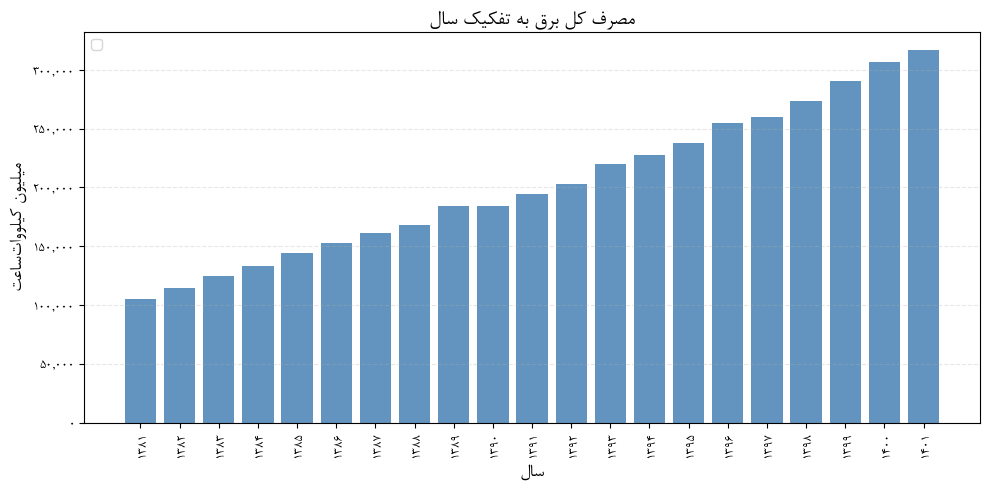

In [33]:
#Group By 
Electricity_By_Year = (
    Energy_By_Activity.groupby('Year', as_index=False)
    .agg(Industry =('Electricity (KWH)', lambda s: s.sum() / 10**6))
)


#Create New Dataset to visualise Electricity usage ratio trend 
Electricity_By_Year = pd.merge(Electricity_By_Year,Electricity_Total[['Year','Total Electricity Consumption (Milion KWH)']],how='inner',on='Year')
Electricity_By_Year.rename(columns={'Total Electricity Consumption (Milion KWH)':'Total'},inplace=True)
Electricity_By_Year['Industry_Ratio'] = Electricity_By_Year['Industry'] / Electricity_By_Year['Total']

fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(Electricity_By_Year['Year'], Electricity_By_Year['Total'],
       color='steelblue', alpha=0.85)

ax.set_xlabel(fa('سال'), fontproperties=bnazanin,fontsize=14)
ax.set_ylabel(fa('میلیون کیلووات‌ساعت'), fontproperties=bnazanin,fontsize=14)
ax.set_title(fa('مصرف کل برق به تفکیک سال'), fontproperties=bnazanin,fontsize=16)

ax.set_xticks(Electricity_By_Year['Year'])
ax.tick_params(axis='x', labelrotation=90)
for t in ax.get_xticklabels():
    t.set_fontproperties(bnazanin)

ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))
for t in ax.get_yticklabels():
    t.set_fontproperties(bnazanin)

ax.grid(axis='y', linestyle='--', alpha=0.3)

leg = ax.legend(loc='upper left')
for t in leg.get_texts():
    t.set_fontproperties(bnazanin)

plt.tight_layout()
plt.show()

C:\Users\hwi\AppData\Local\Temp\ipykernel_7588\4130788831.py:41: UserWarning: Glyph 108 (l) missing from font(s) B Nazanin.
  plt.tight_layout()
C:\Users\hwi\AppData\Local\Temp\ipykernel_7588\4130788831.py:41: UserWarning: Glyph 112 (p) missing from font(s) B Nazanin.
  plt.tight_layout()


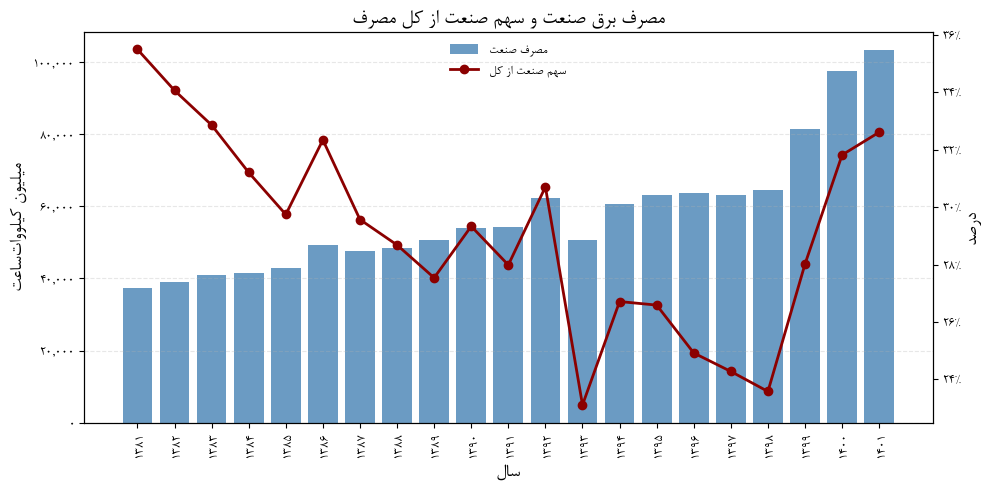

In [34]:
Electricity_By_Year = Electricity_By_Year.sort_values('Year')

fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.bar(Electricity_By_Year['Year'], Electricity_By_Year['Industry'],
        color='steelblue', alpha=0.8, label=fa('مصرف صنعت'))

ax1.set_xlabel(fa('سال'), fontproperties=bnazanin,fontsize=14)
ax1.set_ylabel(fa('میلیون کیلووات‌ساعت'), fontproperties=bnazanin,fontsize=14)
ax1.tick_params(axis='y')
ax1.yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))

ax1.set_xticks(Electricity_By_Year['Year'])
ax1.tick_params(axis='x', labelrotation=90)
for t in ax1.get_xticklabels():
    t.set_fontproperties(bnazanin)
for t in ax1.get_yticklabels():
    t.set_fontproperties(bnazanin)

ax1.grid(axis='y', linestyle='--', alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(Electricity_By_Year['Year'], Electricity_By_Year['Industry_Ratio'],
         color='darkred', linewidth=2, marker='o', label=fa('سهم صنعت از کل'))

ax2.set_ylabel(fa('درصد'), fontproperties=bnazanin,fontsize=14)
ax2.tick_params(axis='y')
ax2.yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:.0%}'))
for t in ax2.get_yticklabels():
    t.set_fontproperties(bnazanin)

ax1.set_title( fa('مصرف برق صنعت و سهم صنعت از کل مصرف'),fontproperties=bnazanin,fontsize=16)

h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
leg = ax1.legend(h1 + h2, l1 + l2, loc='upper center', frameon=False)

for t in leg.get_texts():
    t.set_fontproperties(bnazanin)

plt.tight_layout()
plt.show()

C:\Users\hwi\AppData\Local\Temp\ipykernel_7588\1675386627.py:51: UserWarning: Glyph 108 (l) missing from font(s) B Nazanin.
  plt.tight_layout()
C:\Users\hwi\AppData\Local\Temp\ipykernel_7588\1675386627.py:51: UserWarning: Glyph 112 (p) missing from font(s) B Nazanin.
  plt.tight_layout()
C:\Users\hwi\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 108 (l) missing from font(s) B Nazanin.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hwi\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 112 (p) missing from font(s) B Nazanin.
  fig.canvas.print_figure(bytes_io, **kw)


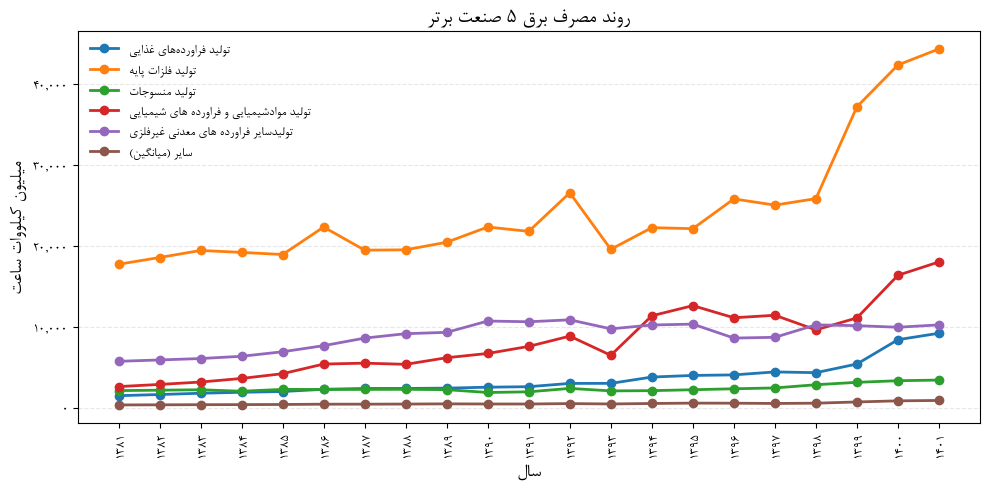

In [35]:
d = (Energy_By_Activity
     .groupby(['Year', 'Industry_Name'], as_index=False)['Electricity (KWH)']
     .sum())
d['M'] = d['Electricity (KWH)'] / 10**6

top5 = (d.groupby('Industry_Name')['M']
          .sum()
          .sort_values(ascending=False)
          .head(5)
          .index)

top_df = d[d['Industry_Name'].isin(top5)].copy()

other_avg = (d[~d['Industry_Name'].isin(top5)]
             .groupby('Year', as_index=False)['M']
             .mean())
other_avg['Industry_Name'] = 'سایر (میانگین)'

plot_df = pd.concat([top_df[['Year','Industry_Name','M']], other_avg[['Year','Industry_Name','M']]],
                    ignore_index=True)

wide = (plot_df.pivot(index='Year', columns='Industry_Name', values='M')
                .sort_index())

fig, ax = plt.subplots(figsize=(10,5))

for col in wide.columns:
    ax.plot(wide.index, wide[col], linewidth=2, marker='o', label=fa(col))

ax.set_title(fa('روند مصرف برق 5 صنعت برتر'),fontproperties=bnazanin,fontsize=16,fontweight='bold')
ax.set_xlabel(fa('سال'), fontproperties=bnazanin,fontsize=14)
ax.set_ylabel(fa('میلیون کیلووات ساعت'), fontproperties=bnazanin,fontsize=14)

ax.set_xticks(wide.index)
ax.tick_params(axis='x', labelrotation=90)
for t in ax.get_xticklabels():
    t.set_fontproperties(bnazanin)

ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))
for t in ax.get_yticklabels():
    t.set_fontproperties(bnazanin)

ax.grid(True, axis='y', linestyle='--', alpha=0.3)

leg = ax.legend(loc='upper left',frameon=False)
leg.get_title().set_fontproperties(bnazanin)

for t in leg.get_texts():
    t.set_fontproperties(bnazanin)

plt.tight_layout()
plt.show()

C:\Users\hwi\AppData\Local\Temp\ipykernel_7588\3542872270.py:47: UserWarning: Glyph 108 (l) missing from font(s) B Nazanin.
  plt.tight_layout()
C:\Users\hwi\AppData\Local\Temp\ipykernel_7588\3542872270.py:47: UserWarning: Glyph 112 (p) missing from font(s) B Nazanin.
  plt.tight_layout()
C:\Users\hwi\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 108 (l) missing from font(s) B Nazanin.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hwi\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 112 (p) missing from font(s) B Nazanin.
  fig.canvas.print_figure(bytes_io, **kw)


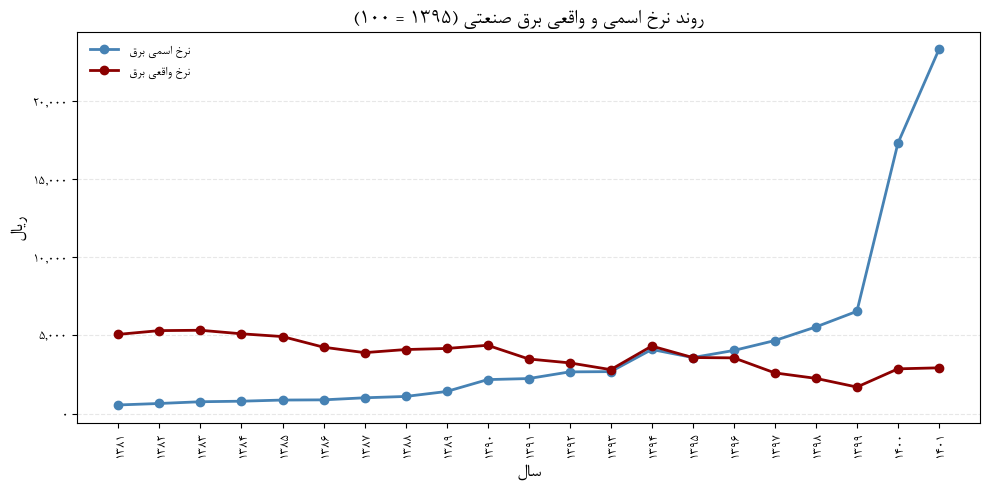

In [36]:
#Group By 
Electricity_Consumption = (
    Energy_By_Activity[['Year','Electricity (KWH)']].groupby('Year', as_index=False)
    .agg( Electricity_KWH =('Electricity (KWH)', lambda s: s.sum()))
)


Electricity_Amount = (
    Energy_Amount[['Year','Electricity']].groupby('Year', as_index=False)
    .agg( Electricity_Amount =('Electricity', lambda s: s.sum() * 10 ** 6))
)

#Create Electricity_Rate Dataset to visualize the trend
Electricity_Rate = pd.merge(Electricity_Consumption,Electricity_Amount,how='inner',on='Year')
Electricity_Rate = pd.merge(Electricity_Rate,PPI,how='inner',on='Year')
Electricity_Rate['Electricity Nominal Rate'] = Electricity_Rate['Electricity_Amount'] / Electricity_Rate['Electricity_KWH']
Electricity_Rate['Electricity Real Rate'] = 100 * Electricity_Rate['Electricity Nominal Rate'] / Electricity_Rate['Price_Index']

Electricity_Rate = Electricity_Rate.sort_values('Year')

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(Electricity_Rate['Year'], Electricity_Rate['Electricity Nominal Rate'],
        color='steelblue', marker='o', linewidth=2, label=fa('نرخ اسمی برق'))

ax.plot(Electricity_Rate['Year'], Electricity_Rate['Electricity Real Rate'],
        color='darkred', marker='o', linewidth=2, label=fa('نرخ واقعی برق'))

ax.set_title(fa('روند نرخ اسمی و واقعی برق صنعتی (1395 = 100)'), fontproperties=bnazanin, fontsize=16)
ax.set_xlabel(fa('سال'), fontproperties=bnazanin, fontsize=14)
ax.set_ylabel(fa('ریال'), fontproperties=bnazanin , fontsize=14)

ax.set_xticks(Electricity_Rate['Year'])
ax.tick_params(axis='x', labelrotation=90)

ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))

ax.grid(axis='y', linestyle='--', alpha=0.3)

leg = ax.legend(frameon=False, loc='upper left')
for t in leg.get_texts():
    t.set_fontproperties(bnazanin)

for t in ax.get_xticklabels() + ax.get_yticklabels():
    t.set_fontproperties(bnazanin)

plt.tight_layout()
plt.show()

C:\Users\hwi\AppData\Local\Temp\ipykernel_7588\628902010.py:54: UserWarning: Glyph 108 (l) missing from font(s) B Nazanin.
  plt.tight_layout()
C:\Users\hwi\AppData\Local\Temp\ipykernel_7588\628902010.py:54: UserWarning: Glyph 112 (p) missing from font(s) B Nazanin.
  plt.tight_layout()
C:\Users\hwi\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 108 (l) missing from font(s) B Nazanin.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hwi\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 112 (p) missing from font(s) B Nazanin.
  fig.canvas.print_figure(bytes_io, **kw)


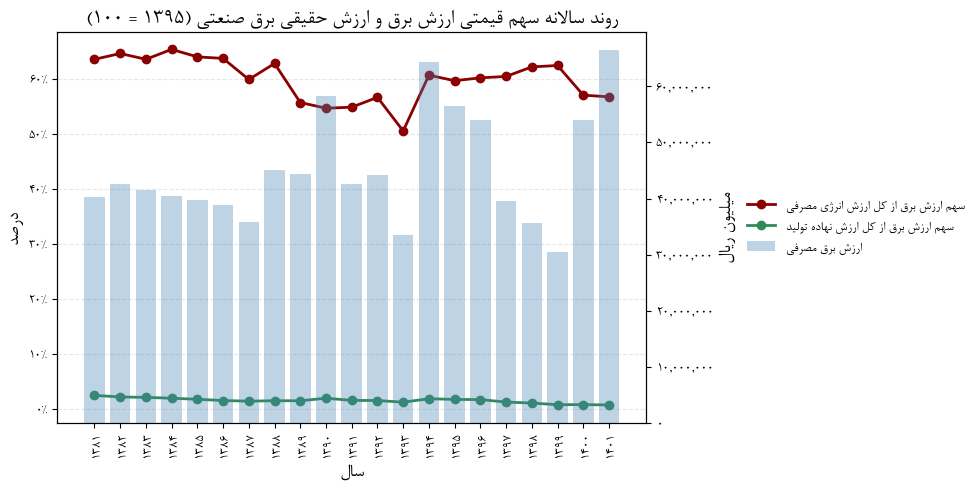

In [37]:
Electricity_expences_By_Year = (
    Dataset_For_Model
    .groupby(['Year'], as_index=False)
    .agg(
        Elec_value_intensity=('Elec_value_intensity', 'mean'),
        Elec_value_share_of_input=('Elec_value_share_of_input', 'mean'),
        Elec_value=('Electricity', 'sum')
    )
)

df = Electricity_expences_By_Year.sort_values('Year').copy()
df['Elec_value_million'] = df['Elec_value'] / 1_000_000

fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(df['Year'], df['Elec_value_intensity'],
         color='darkred', marker='o', linewidth=2, label=fa('سهم ارزش برق از کل ارزش انرژی مصرفی'))
ax1.plot(df['Year'], df['Elec_value_share_of_input'],
         color='seagreen', marker='o', linewidth=2, label=fa('سهم ارزش برق از کل ارزش نهاده تولید'))

ax1.set_xlabel(fa('سال'), fontproperties=bnazanin,fontsize = 14)
ax1.set_ylabel(fa('درصد'), fontproperties=bnazanin,fontsize = 14)
ax1.set_xticks(df['Year'])
ax1.tick_params(axis='x', labelrotation=90)
ax1.yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:.0%}'))

ax2 = ax1.twinx()
ax2.bar(df['Year'], df['Elec_value_million'],
        color='steelblue', alpha=0.35, label=fa('ارزش برق مصرفی'))

ax2.set_ylabel(fa('میلیون ریال'), fontproperties=bnazanin,fontsize = 14)
ax2.yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))

for t in ax1.get_xticklabels() + ax1.get_yticklabels() + ax2.get_yticklabels():
    t.set_fontproperties(bnazanin)

ax1.grid(axis='y', linestyle='--', alpha=0.3)

h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
leg = ax1.legend(
    h1 + h2, l1 + l2,
    frameon=False,
    loc='center left',
    bbox_to_anchor=(1.15, 0.5)
)
for t in leg.get_texts():
    t.set_fontproperties(bnazanin)

ax1.set_title(fa('روند سالانه سهم قیمتی ارزش برق و ارزش حقیقی برق صنعتی (1395 = 100)'),
              fontproperties=bnazanin, fontsize=16, fontweight='bold')

fig.subplots_adjust(right=0.78)
plt.tight_layout()
plt.show()

C:\Users\hwi\AppData\Local\Temp\ipykernel_7588\412052535.py:69: UserWarning: Glyph 108 (l) missing from font(s) B Nazanin.
  plt.tight_layout()
C:\Users\hwi\AppData\Local\Temp\ipykernel_7588\412052535.py:69: UserWarning: Glyph 112 (p) missing from font(s) B Nazanin.
  plt.tight_layout()
C:\Users\hwi\AppData\Local\Temp\ipykernel_7588\412052535.py:69: UserWarning: Glyph 8211 (\N{EN DASH}) missing from font(s) B Nazanin.
  plt.tight_layout()
C:\Users\hwi\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 108 (l) missing from font(s) B Nazanin.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hwi\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 112 (p) missing from font(s) B Nazanin.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hwi\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8211 (\N{EN DASH}) missing from font(s) B Nazanin.
  fig.can

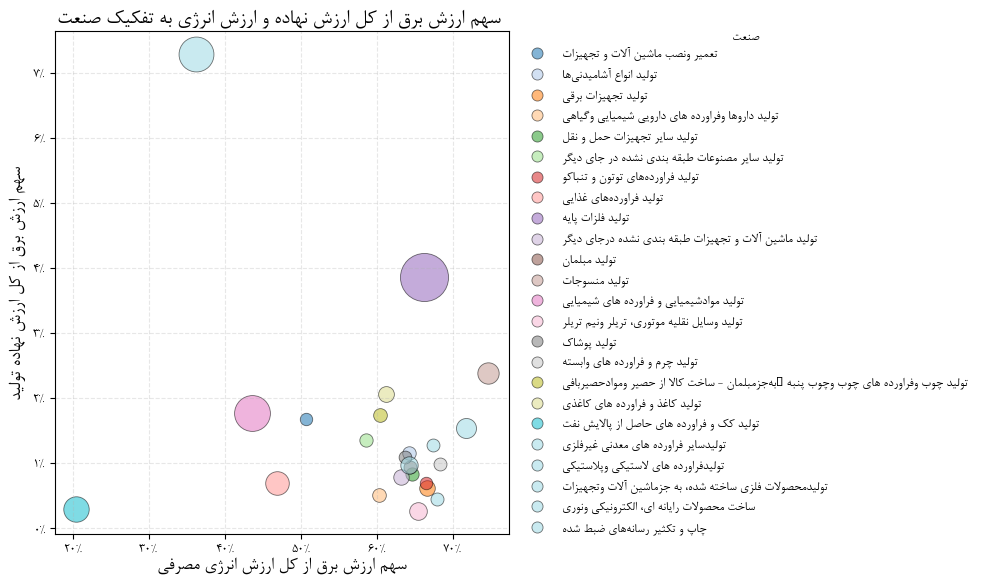

In [38]:
Electricity_expences_By_Industry = (
    Dataset_For_Model
    .groupby(['Industry_Name'], as_index=False)
    .agg(
        Elec_value_intensity=('Elec_value_intensity', 'mean'),
        Elec_value_share_of_input=('Elec_value_share_of_input', 'mean'),
        Elec_value=('Electricity', 'sum')
    )
)

df = Electricity_expences_By_Industry.copy().sort_values('Industry_Name')

raw = df['Elec_value'].to_numpy(dtype=float)
s_min, s_max = 80, 1200
if np.nanmax(raw) == np.nanmin(raw):
    df['bubble_size'] = (s_min + s_max) / 2
else:
    df['bubble_size'] = s_min + (raw - np.nanmin(raw)) * (s_max - s_min) / (np.nanmax(raw) - np.nanmin(raw))

fig, ax = plt.subplots(figsize=(10, 6))
colors = plt.cm.tab20(range(len(df)))

for i, (_, r) in enumerate(df.iterrows()):
    ax.scatter(
        r['Elec_value_intensity'],
        r['Elec_value_share_of_input'],
        s=r['bubble_size'],
        alpha=0.55,
        color=colors[i],
        edgecolor='black',
        linewidth=0.6,
        label=fa(r['Industry_Name'])
    )

ax.set_title(fa(' سهم ارزش برق از کل ارزش نهاده و ارزش انرژی به تفکیک صنعت'),
             fontproperties=bnazanin, fontsize=16, fontweight='bold')
ax.set_xlabel(fa('سهم ارزش برق از کل ارزش انرژی مصرفی'), fontproperties=bnazanin ,fontsize=14)
ax.set_ylabel(fa('سهم ارزش برق از کل ارزش نهاده تولید'), fontproperties=bnazanin ,fontsize=14)

ax.xaxis.set_major_formatter(mtick.StrMethodFormatter('{x:.0%}'))
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:.0%}'))

for t in ax.get_xticklabels() + ax.get_yticklabels():
    t.set_fontproperties(bnazanin)

ax.grid(True, linestyle='--', alpha=0.3)

leg = ax.legend(
    title=fa('صنعت'),
    frameon=False,
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),
    borderaxespad=0.0,
    scatterpoints=1,
    markerscale=1.0
)
leg.get_title().set_fontproperties(bnazanin)
leg.get_title().set_fontweight('bold')
for t in leg.get_texts():
    t.set_fontproperties(bnazanin)

legend_marker_size = 8
for h in leg.legend_handles:
    try:
        h.set_sizes([legend_marker_size**2])
    except Exception:
        pass

plt.tight_layout()
plt.show()

C:\Users\hwi\AppData\Local\Temp\ipykernel_7588\2686971768.py:85: UserWarning: Glyph 108 (l) missing from font(s) B Nazanin.
  plt.tight_layout()
C:\Users\hwi\AppData\Local\Temp\ipykernel_7588\2686971768.py:85: UserWarning: Glyph 112 (p) missing from font(s) B Nazanin.
  plt.tight_layout()
C:\Users\hwi\AppData\Local\Temp\ipykernel_7588\2686971768.py:85: UserWarning: Glyph 8211 (\N{EN DASH}) missing from font(s) B Nazanin.
  plt.tight_layout()
C:\Users\hwi\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 108 (l) missing from font(s) B Nazanin.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hwi\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 112 (p) missing from font(s) B Nazanin.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hwi\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8211 (\N{EN DASH}) missing from font(s) B Nazanin.
  fig.

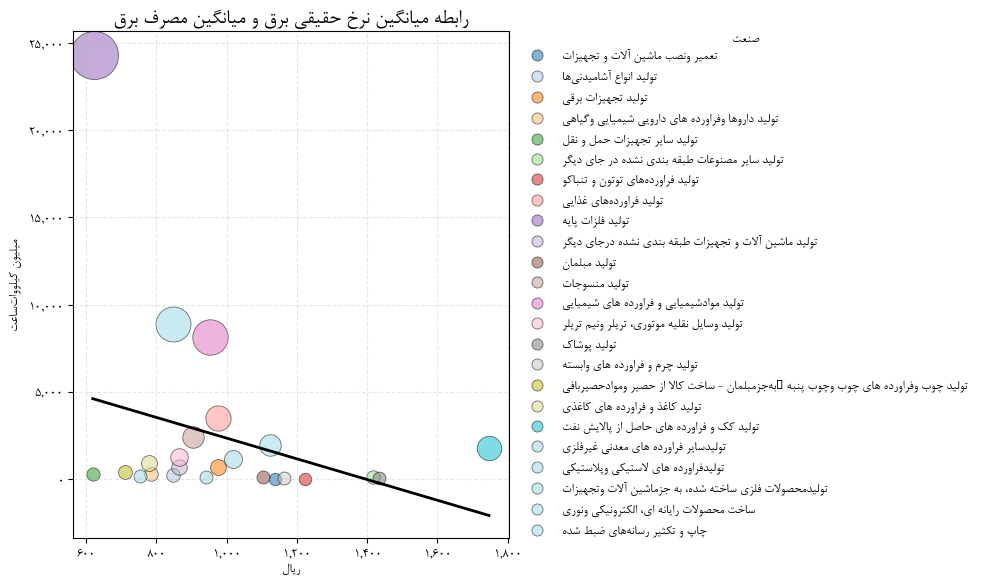

In [39]:
Energy_Real_Rate = (
    Energy_Real_Rate.groupby('Industry_Name', as_index=False)
    .agg(Electricity_unit_price=('Electricity_unit_price', lambda s: s.mean() * 10**6))
)

Energy_Usage = (
    Energy_By_Activity.groupby('Industry_Name', as_index=False)
    .agg(Electricity_KWH=('Electricity (KWH)', lambda s: s.mean() / 10**6))
)

df = (pd.merge(Energy_Real_Rate, Energy_Usage, on='Industry_Name', how='inner')
      .sort_values('Industry_Name')
      .copy())

df['bubble_raw'] = df['Electricity_KWH'] * df['Electricity_unit_price']

s_min, s_max = 80, 1200
raw = df['bubble_raw'].to_numpy()

if np.nanmax(raw) == np.nanmin(raw):
    df['bubble_size'] = (s_min + s_max) / 2
else:
    df['bubble_size'] = s_min + (raw - np.nanmin(raw)) * (s_max - s_min) / (np.nanmax(raw) - np.nanmin(raw))

fig, ax = plt.subplots(figsize=(10, 6))
colors = plt.cm.tab20(range(len(df)))

for i, (_, r) in enumerate(df.iterrows()):
    ax.scatter(
        r['Electricity_unit_price'],
        r['Electricity_KWH'],
        s=r['bubble_size'],
        alpha=0.55,
        color=colors[i],
        edgecolor='black',
        linewidth=0.6,
        label=fa(r['Industry_Name'])
    )

x = df['Electricity_unit_price'].to_numpy(dtype=float)
y = df['Electricity_KWH'].to_numpy(dtype=float)
m = np.isfinite(x) & np.isfinite(y)

coef = np.polyfit(x[m], y[m], 1)
xx = np.linspace(x[m].min(), x[m].max(), 200)
yy = coef[0] * xx + coef[1]
ax.plot(xx, yy, color='black', linewidth=2)

ax.set_title(fa('رابطه میانگین نرخ حقیقی برق و میانگین مصرف برق'),
             fontproperties=bnazanin, fontsize=16, fontweight='bold')
ax.set_xlabel(fa('ریال'), fontproperties=bnazanin)
ax.set_ylabel(fa('میلیون کیلووات‌ساعت'), fontproperties=bnazanin)

ax.ticklabel_format(style='plain', axis='both', useOffset=False)
ax.xaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))

for t in ax.get_xticklabels() + ax.get_yticklabels():
    t.set_fontproperties(bnazanin)

ax.grid(True, linestyle='--', alpha=0.3)

leg = ax.legend(
    title=fa('صنعت'),
    frameon=False,
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),
    borderaxespad=0.0,
    scatterpoints=1,
    markerscale=1.0
)

leg.get_title().set_fontproperties(bnazanin)
leg.get_title().set_fontweight('bold')
for t in leg.get_texts():
    t.set_fontproperties(bnazanin)

legend_marker_size = 8
for h in leg.legend_handles:
    try:
        h.set_sizes([legend_marker_size**2])
    except Exception:
        pass

plt.tight_layout()
plt.show()

C:\Users\hwi\AppData\Local\Temp\ipykernel_7588\3164814056.py:32: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  leg = ax.legend(frameon=False, loc='lower right')
C:\Users\hwi\AppData\Local\Temp\ipykernel_7588\3164814056.py:49: UserWarning: Glyph 108 (l) missing from font(s) B Nazanin.
  plt.tight_layout()
C:\Users\hwi\AppData\Local\Temp\ipykernel_7588\3164814056.py:49: UserWarning: Glyph 112 (p) missing from font(s) B Nazanin.
  plt.tight_layout()
C:\Users\hwi\AppData\Local\Temp\ipykernel_7588\3164814056.py:49: UserWarning: Glyph 8211 (\N{EN DASH}) missing from font(s) B Nazanin.
  plt.tight_layout()
C:\Users\hwi\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 108 (l) missing from font(s) B Nazanin.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hwi\AppData\Roaming\Python\Python312\site-packages\IPython\core\p

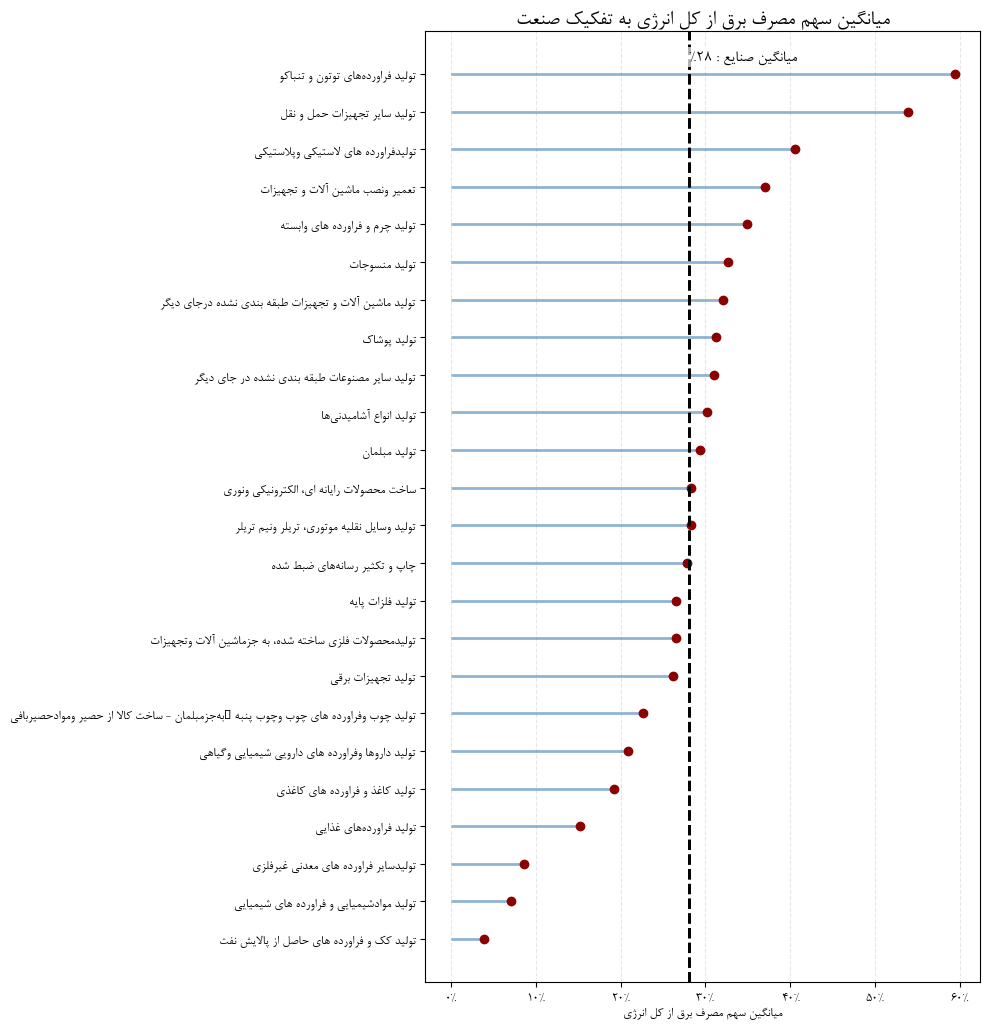

In [40]:
avg_df = (Energy_By_Activity
          .groupby('Industry_Name', as_index=False)['Elec_boe_intensity']
          .mean()
          .rename(columns={'Elec_boe_intensity': 'avg'}))

avg_df = avg_df.sort_values('avg', ascending=True)

overall_avg = Energy_By_Activity['Elec_boe_intensity'].mean()

fig, ax = plt.subplots(figsize=(10, 0.35 * len(avg_df) + 2))
y = range(len(avg_df))

ax.hlines(y=y, xmin=0, xmax=avg_df['avg'], color='steelblue', alpha=0.6, linewidth=2)
ax.plot(avg_df['avg'], y, 'o', color='darkred', markersize=6)

ax.set_yticks(list(y))
ax.set_yticklabels([fa(s) for s in avg_df['Industry_Name']], fontproperties=bnazanin)

ax.xaxis.set_major_formatter(mtick.StrMethodFormatter('{x:.0%}'))

ax.axvline(overall_avg, color='black', linestyle='--', linewidth=2)

ax.set_xlabel(fa('میانگین سهم مصرف برق از کل انرژی'), fontproperties=bnazanin)
ax.set_title(fa('میانگین سهم مصرف برق از کل انرژی به تفکیک صنعت'), 
             fontproperties=bnazanin, fontsize=16, fontweight='bold')

ax.grid(axis='x', linestyle='--', alpha=0.3)

for t in ax.get_xticklabels():
    t.set_fontproperties(bnazanin)

leg = ax.legend(frameon=False, loc='lower right')
for t in leg.get_texts():
    t.set_fontproperties(bnazanin)

ax.axvline(overall_avg, color='black', linestyle='--', linewidth=2)

ax.text(
    overall_avg, 0.98, 
    fa(f" میانگین صنایع : {overall_avg:.0%}"),
    transform=ax.get_xaxis_transform(), 
    ha='left', va='top',
    fontproperties=bnazanin,
    fontsize=12,
    color='black',
    bbox=dict(facecolor='white', edgecolor='none', alpha=0.7, pad=2)
)

plt.tight_layout()
plt.show()

C:\Users\hwi\AppData\Local\Temp\ipykernel_7588\1543983786.py:45: UserWarning: Glyph 108 (l) missing from font(s) B Nazanin.
  plt.tight_layout()
C:\Users\hwi\AppData\Local\Temp\ipykernel_7588\1543983786.py:45: UserWarning: Glyph 112 (p) missing from font(s) B Nazanin.
  plt.tight_layout()
C:\Users\hwi\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 108 (l) missing from font(s) B Nazanin.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hwi\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 112 (p) missing from font(s) B Nazanin.
  fig.canvas.print_figure(bytes_io, **kw)


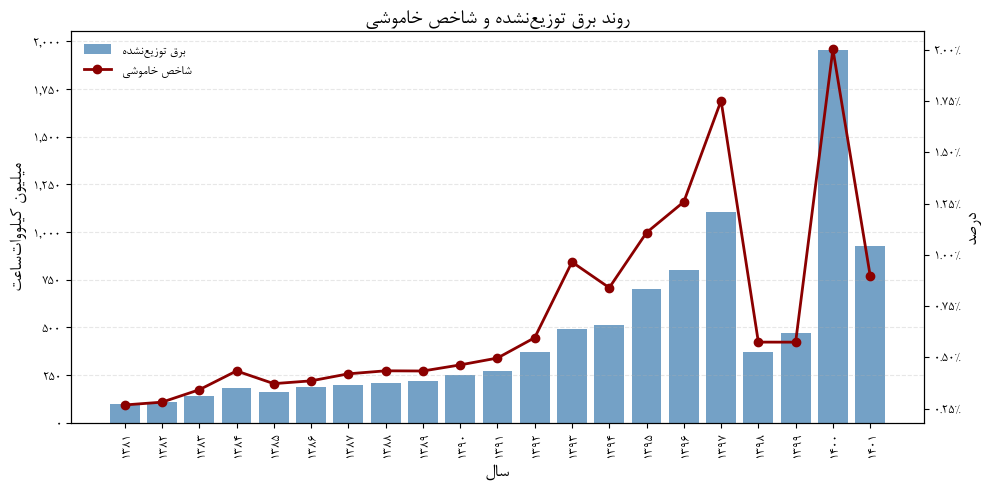

In [41]:
Blackout = Electricity_Total[['Year',
                              'Total Section Not Distributed Electricity (Milion KWH)',
                              'Blackout']].copy().sort_values('Year')

fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.bar(
    Blackout['Year'],
    Blackout['Total Section Not Distributed Electricity (Milion KWH)'],
    color='steelblue', alpha=0.75,
    label=fa('برق توزیع‌نشده')
)

ax1.set_xlabel(fa('سال'), fontproperties=bnazanin, fontsize=14)
ax1.set_ylabel(fa('میلیون کیلووات‌ساعت'), fontproperties=bnazanin, fontsize=14)
ax1.set_xticks(Blackout['Year'])
ax1.tick_params(axis='x', labelrotation=90)
ax1.yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))

ax2 = ax1.twinx()
ax2.plot(
    Blackout['Year'],
    Blackout['Blackout'],
    color='darkred', marker='o', linewidth=2,
    label=fa('شاخص خاموشی')
)

ax2.set_ylabel(fa('درصد'), fontproperties=bnazanin, fontsize=14)
ax2.yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:.2%}'))

for t in ax1.get_xticklabels() + ax1.get_yticklabels() + ax2.get_yticklabels():
    t.set_fontproperties(bnazanin)

ax1.grid(axis='y', linestyle='--', alpha=0.3)

h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
leg = ax1.legend(h1 + h2, l1 + l2, frameon=False, loc='upper left')
for t in leg.get_texts():
    t.set_fontproperties(bnazanin)

ax1.set_title(fa('روند برق توزیع‌نشده و شاخص خاموشی'), fontproperties=bnazanin, fontsize=16, fontweight='bold')

fig.subplots_adjust(right=0.72)
plt.tight_layout()
plt.show()